## 0. Install dependencies

## 1. Config

In [216]:
from pathlib import Path

CONFIG = {
    "MODEL_PATH": "runs/detect/dcp1_exp1-9/weights/best.pt",   # <-- your trained model
    "FOG_MODEL_PATH": "fog_model.pkl",                        # <-- fitted fog/clear classifier from the training notebook
    "INPUT_PATH": r"G:\Downloads\bikes_and_cars.mp4",                    # <-- image or video to run on
    "OUTPUT_DIR": "data/inference_output",

    # --- sampling: None = every frame at the video's own native fps (what ByteTrack expects).
    # Set to a number (e.g. 5) to sample at that many frames per second instead. ---
    "TARGET_FPS": 20,

    "CONF_THRESHOLD": 0.25,
    "IMGSZ": 640,           # matches training IMG_SIZE
    "DEVICE": 0,            # RTX 4050
    "QUANTIZE": 16,
    "SHOW_PREVIEW": True,

    # --- ByteTrack settings (video only) ---
    "TRACKER_CONFIG": "bytetrack.yaml",   # Ultralytics' built-in ByteTrack config
    "PERSIST_TRACKS": True,               # keep track IDs alive across the model.track() calls in the loop below

    # --- fog scoring (must match the training notebook's fog_classifier settings) ---
    "SCORE_RESOLUTION": (256, 256),
    "DARK_CHANNEL_PATCH": 15,

    # --- annotation display ---
    "PLOT_LINE_WIDTH": 2,

    "MODEL_SIZE": 640,

    "RESIZE_MODE": "keep_aspect",

    "MAX_WIDTH": 1280,  
    "MAX_HEIGHT": 720,
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".webm", ".m4v"}

out_dir = Path(CONFIG["OUTPUT_DIR"])
out_dir.mkdir(parents=True, exist_ok=True)

## 2. Load the detection model and confirm GPU is actually being used

In [217]:
import torch
from ultralytics import YOLO

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(CONFIG["DEVICE"]))
else:
    print("[warn] CUDA not available — falls back to CPU, which will be much slower at native frame rate")

model = YOLO(CONFIG["MODEL_PATH"])
print(model.names)

CUDA available: True
Device: NVIDIA GeForce RTX 4050 Laptop GPU
{0: 'Bike-car-person', 1: 'Bike', 2: 'Car', 3: 'Person'}


## 3. Load the fog classifier + DCP/exposure functions


In [218]:
import cv2
import numpy as np
import joblib
import pandas as pd

fog_model = joblib.load(CONFIG["FOG_MODEL_PATH"])
fog_scaler, fog_kmeans, fog_cluster = fog_model["scaler"], fog_model["kmeans"], fog_model["fog_cluster"]


def classify_frame(img_bgr):
    """Returns 'fog' or 'clear' using the model fitted in the training notebook."""
    img = cv2.resize(img_bgr, CONFIG["SCORE_RESOLUTION"], interpolation=cv2.INTER_AREA)
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (CONFIG["DARK_CHANNEL_PATCH"],) * 2)
    dark_channel_small = cv2.erode(min_channel, kernel)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    feats = pd.DataFrame([[
        np.mean(dark_channel_small),
        cv2.Laplacian(gray, cv2.CV_64F).var(),
        np.mean(hsv[:, :, 1]),
    ]], columns=fog_scaler.feature_names_in_)
    cluster = fog_kmeans.predict(fog_scaler.transform(feats))[0]
    return "fog" if cluster == fog_cluster else "clear"


def dark_channel(img, patch=15):
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
    return cv2.erode(min_channel, kernel)


def estimate_atmospheric_light(img, dark, top_percent=0.001):
    h, w = dark.shape
    n_pixels = max(int(h * w * top_percent), 1)
    flat_dark = dark.reshape(-1)
    flat_img = img.reshape(-1, 3)
    idx = np.argpartition(flat_dark, -n_pixels)[-n_pixels:]
    brightest = idx[np.argmax(flat_img[idx].sum(axis=1))]
    return flat_img[brightest].astype(np.float64)


def guided_filter(guide, src, radius=40, eps=1e-3):
    guide = guide.astype(np.float64)
    src = src.astype(np.float64)
    mean_g = cv2.boxFilter(guide, cv2.CV_64F, (radius, radius))
    mean_s = cv2.boxFilter(src, cv2.CV_64F, (radius, radius))
    mean_gs = cv2.boxFilter(guide * src, cv2.CV_64F, (radius, radius))
    cov_gs = mean_gs - mean_g * mean_s
    mean_gg = cv2.boxFilter(guide * guide, cv2.CV_64F, (radius, radius))
    var_g = mean_gg - mean_g * mean_g
    a = cov_gs / (var_g + eps)
    b = mean_s - a * mean_g
    mean_a = cv2.boxFilter(a, cv2.CV_64F, (radius, radius))
    mean_b = cv2.boxFilter(b, cv2.CV_64F, (radius, radius))
    return mean_a * guide + mean_b


def estimate_transmission(img, A, patch=15, omega=0.95):
    normalized = img.astype(np.float64) / A
    return 1 - omega * dark_channel(normalized, patch)


def dehaze(img_bgr, patch=15, omega=0.95, t0=0.1, guide_radius=40, guide_eps=1e-3):
    img = img_bgr.astype(np.float64)
    dark = dark_channel(img, patch)
    A = estimate_atmospheric_light(img, dark)
    t = estimate_transmission(img, A, patch, omega)
    gray_guide = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
    t_refined = guided_filter(gray_guide, t, radius=guide_radius, eps=guide_eps)
    t_refined = np.clip(t_refined, t0, 1.0)
    J = np.empty_like(img)
    for c in range(3):
        J[:, :, c] = (img[:, :, c] - A[c]) / t_refined + A[c]
    return np.clip(J, 0, 255).astype(np.uint8)


def enhance_exposure(img_bgr, clip_limit=2.0, tile_grid_size=(8, 8)):
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l_channel)
    lab_eq = cv2.merge((l_eq, a_channel, b_channel))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)


def resize_for_model(frame_bgr):
    """Caps the frame at 720p, then makes the 640 model frame from that.
    Returns (original_720p, small, sx, sy); sx/sy map small-frame coords to the 720p frame."""
    h, w = frame_bgr.shape[:2]
    cap = min(CONFIG["MAX_WIDTH"] / w, CONFIG["MAX_HEIGHT"] / h, 1.0)
    if cap < 1.0:
        frame_bgr = cv2.resize(frame_bgr, (round(w * cap), round(h * cap)), interpolation=cv2.INTER_AREA)
        h, w = frame_bgr.shape[:2]

    size = CONFIG["MODEL_SIZE"]
    if CONFIG["RESIZE_MODE"] == "stretch":
        new_w, new_h = size, size
    else:
        scale = size / max(w, h)
        new_w, new_h = max(int(round(w * scale)), 1), max(int(round(h * scale)), 1)
    small = cv2.resize(frame_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    return frame_bgr, small, w / new_w, h / new_h


def preprocess_for_model(small_bgr):
    """Fog gate -> DCP -> exposure on the already-resized frame, mirroring training."""
    if classify_frame(small_bgr) == "fog":
        return enhance_exposure(dehaze(small_bgr))
    return small_bgr


def rescale_result_to_original(result, original, sx, sy):
    """Result boxes are in small-frame coords; scale them to the original frame so
    plotting and the saved CSV are in original-resolution pixels."""
    result.orig_shape = original.shape[:2]
    if len(result.boxes):
        data = result.boxes.data.clone()
        data[:, [0, 2]] *= sx
        data[:, [1, 3]] *= sy
        result.update(boxes=data)
    return result

## 4. Detect whether the input is an image or a video

In [219]:
input_path = Path(CONFIG["INPUT_PATH"])
if not input_path.exists():
    raise FileNotFoundError(f"INPUT_PATH does not exist: {input_path}")

ext = input_path.suffix.lower()
if ext in IMAGE_EXTS:
    input_type = "image"
elif ext in VIDEO_EXTS:
    input_type = "video"
else:
    raise ValueError(
        f"Unrecognized extension '{ext}'. Known image types: {IMAGE_EXTS}. Known video types: {VIDEO_EXTS}. "
        "Add the extension to one of those sets above if it's a valid file just not listed."
    )

print(f"Detected input type: {input_type}")

Detected input type: video


## 5a. If it's an image: preprocess -> detect -> plot on the ORIGINAL frame

In [220]:
import time
import pandas as pd

detections = []

if input_type == "image":
    original = cv2.imread(str(input_path))
    original, small, sx, sy = resize_for_model(cv2.imread(str(input_path)))

    result = model.predict(
        model_input,
        conf=CONFIG["CONF_THRESHOLD"],
        imgsz=CONFIG["IMGSZ"],
        device=CONFIG["DEVICE"],
        quantize=CONFIG["QUANTIZE"],
        verbose=False,
    )[0]

    # boxes are in small-frame coords -> scale to the original frame, then plot on the original
    result = rescale_result_to_original(result, original, sx, sy)
    annotated = result.plot(img=original.copy(),  line_width=CONFIG["PLOT_LINE_WIDTH"])

    out_path = out_dir / f"{input_path.stem}_annotated.jpg"
    cv2.imwrite(str(out_path), annotated)

    boxes = result.boxes.xyxy.cpu().numpy() if len(result.boxes) else []
    confs = result.boxes.conf.cpu().numpy() if len(result.boxes) else []
    classes = result.boxes.cls.cpu().numpy().astype(int) if len(result.boxes) else []
    for (x1, y1, x2, y2), conf, cls in zip(boxes, confs, classes):
        detections.append({
            "source": input_path.name, "frame_time_sec": None, "track_id": None,
            "class": model.names[cls], "confidence": float(conf),
            "x1": float(x1), "y1": float(y1), "x2": float(x2), "y2": float(y2),
        })

    print(f"{len(boxes)} detections, saved annotated image to {out_path}")

    if CONFIG["SHOW_PREVIEW"]:
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 8))
        plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

## 5b. If it's a video: preprocess each frame -> ByteTrack -> plot on the ORIGINAL frame



Video FPS: 25.00 | total frames: 867 | sampling every 1 frame(s)
  100 frames processed | 5.5 fps actual throughput | 100 flagged foggy so far
  200 frames processed | 5.6 fps actual throughput | 200 flagged foggy so far
  300 frames processed | 5.6 fps actual throughput | 300 flagged foggy so far
  400 frames processed | 5.6 fps actual throughput | 400 flagged foggy so far
  500 frames processed | 5.6 fps actual throughput | 500 flagged foggy so far
  600 frames processed | 5.6 fps actual throughput | 600 flagged foggy so far
  700 frames processed | 5.6 fps actual throughput | 700 flagged foggy so far
  800 frames processed | 5.7 fps actual throughput | 800 flagged foggy so far
Done: 867 frames in 153.5s (5.6 fps actual throughput), 867 frames routed through DCP+exposure -> data\inference_output\bikes_and_cars_frames


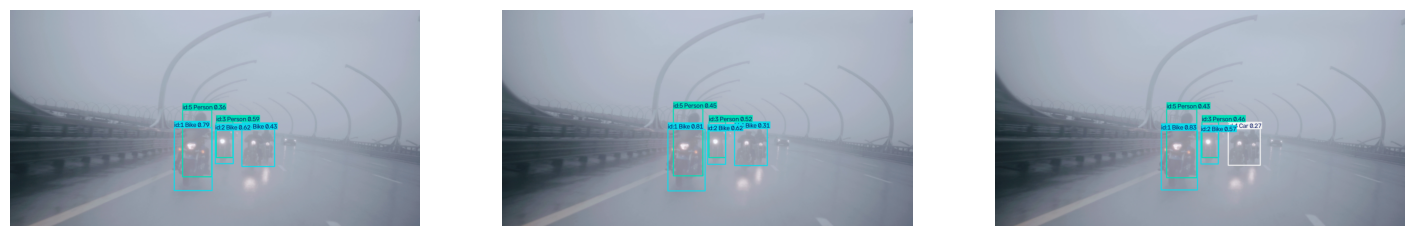

In [221]:
if input_type == "video":
    cap = cv2.VideoCapture(str(input_path))
    fps = cap.get(cv2.CAP_PROP_FPS)
    if not fps or fps <= 0:
        print("[warn] video reported an invalid FPS; assuming 30 fps")
        fps = 30.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    frame_interval = 1 if not CONFIG["TARGET_FPS"] else max(int(round(fps / CONFIG["TARGET_FPS"])), 1)
    print(f"Video FPS: {fps:.2f} | total frames: {total_frames} | sampling every {frame_interval} frame(s)")

    frames_dir = out_dir / f"{input_path.stem}_frames"
    frames_dir.mkdir(parents=True, exist_ok=True)

    frame_idx = 0
    saved_idx = 0
    preview_frames = []
    fog_frame_count = 0
    t_start = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % frame_interval == 0:
            timestamp_sec = frame_idx / fps
            original = frame  # untouched full-res frame, used only for display/saving

            # resize once, then fog gate + DCP + CLAHE + YOLO all run on the small frame
            original, small, sx, sy = resize_for_model(frame)  
            model_input = preprocess_for_model(small)
            if model_input is not small:
                fog_frame_count += 1

            result = model.track(
                model_input,
                conf=CONFIG["CONF_THRESHOLD"],
                imgsz=CONFIG["IMGSZ"],
                device=CONFIG["DEVICE"],
                quantize=CONFIG["QUANTIZE"],
                persist=CONFIG["PERSIST_TRACKS"],
                tracker=CONFIG["TRACKER_CONFIG"],
                verbose=False,
            )[0]

            # tracking happened in small-frame coords; scale boxes up to the original before plotting/saving
            result = rescale_result_to_original(result, original, sx, sy)
            annotated = result.plot(
                img=original.copy(),
                line_width=CONFIG["PLOT_LINE_WIDTH"],
            )

            out_path = frames_dir / f"frame_{saved_idx:05d}_t{timestamp_sec:.1f}s.jpg"
            cv2.imwrite(str(out_path), annotated)
            if len(preview_frames) < 3:
                preview_frames.append(annotated)

            boxes = result.boxes.xyxy.cpu().numpy() if len(result.boxes) else []
            confs = result.boxes.conf.cpu().numpy() if len(result.boxes) else []
            classes = result.boxes.cls.cpu().numpy().astype(int) if len(result.boxes) else []
            track_ids = (
                result.boxes.id.cpu().numpy().astype(int).tolist()
                if result.boxes.id is not None else [None] * len(boxes)
            )

            for (x1, y1, x2, y2), conf, cls, tid in zip(boxes, confs, classes, track_ids):
                detections.append({
                    "source": input_path.name, "frame_time_sec": round(timestamp_sec, 2), "track_id": tid,
                    "class": model.names[cls], "confidence": float(conf),
                    "x1": float(x1), "y1": float(y1), "x2": float(x2), "y2": float(y2),
                })

            saved_idx += 1
            if saved_idx % 100 == 0:
                elapsed = time.time() - t_start
                print(f"  {saved_idx} frames processed | {saved_idx / elapsed:.1f} fps actual throughput | "
                      f"{fog_frame_count} flagged foggy so far")
        frame_idx += 1

    cap.release()
    elapsed = time.time() - t_start
    print(f"Done: {saved_idx} frames in {elapsed:.1f}s ({saved_idx / elapsed:.1f} fps actual throughput), "
          f"{fog_frame_count} frames routed through DCP+exposure -> {frames_dir}")

    if CONFIG["SHOW_PREVIEW"] and preview_frames:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, len(preview_frames), figsize=(6 * len(preview_frames), 6))
        axes = [axes] if len(preview_frames) == 1 else axes
        for ax, f in zip(axes, preview_frames):
            ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
            ax.axis("off")
        plt.show()

## 6. Stitch the annotated frames into a preview video


In [222]:
if input_type == "video":
    frame_files = sorted(frames_dir.glob("frame_*.jpg"))
    if frame_files:
        sample = cv2.imread(str(frame_files[0]))
        h, w = sample.shape[:2]
        preview_fps = fps / frame_interval
        out_video_path = out_dir / f"{input_path.stem}_tracked_preview.mp4"
        writer = cv2.VideoWriter(str(out_video_path), cv2.VideoWriter_fourcc(*"mp4v"), preview_fps, (w, h))
        for f in frame_files:
            writer.write(cv2.imread(str(f)))
        writer.release()
        print(f"Saved preview video to {out_video_path} at {preview_fps:.2f} fps")

Saved preview video to data\inference_output\bikes_and_cars_tracked_preview.mp4 at 25.00 fps


## 7. Save all detections/tracks to a CSV


In [223]:
det_df = pd.DataFrame(detections)
det_path = out_dir / f"{input_path.stem}_detections.csv"
det_df.to_csv(det_path, index=False)
print(f"Saved {len(det_df)} detections to {det_path}")
if input_type == "video" and not det_df.empty:
    print(f"Unique tracked objects (excluding unconfirmed track_id=None): {det_df['track_id'].dropna().nunique()}")
det_df.head(20)

Saved 6190 detections to data\inference_output\bikes_and_cars_detections.csv
Unique tracked objects (excluding unconfirmed track_id=None): 89


,source,frame_time_sec,track_id,class,confidence,x1,y1,x2,y2
0,bikes_and_cars.mp4,0.00,1,Bike,0.788086,512.000000,368.454163,630.000000,564.164185
1,bikes_and_cars.mp4,0.00,2,Bike,0.622559,640.000000,376.941589,696.000000,480.288483
2,bikes_and_cars.mp4,0.00,3,Person,0.594727,643.000000,350.480774,695.000000,461.316589
3,bikes_and_cars.mp4,0.00,4,Bike,0.430176,723.000000,373.446747,825.000000,489.275146
4,bikes_and_cars.mp4,0.00,5,Person,0.359375,538.000000,313.535522,629.000000,521.227844
5,bikes_and_cars.mp4,0.04,1,Bike,0.813965,516.727844,373.653046,632.214294,565.030701
6,bikes_and_cars.mp4,0.04,2,Bike,0.624512,640.848145,378.891174,696.887390,482.238068
7,bikes_and_cars.mp4,0.04,3,Person,0.523438,644.616577,350.697418,696.854492,461.966431
8,bikes_and_cars.mp4,0.04,4,Bike,0.312256,724.755127,370.630676,826.715942,486.459076
9,bikes_and_cars.mp4,0.04,5,Person,0.450439,533.035522,308.769836,625.286804,518.195129


## 8. Optional Cell to see DCP + SCAHE output for random frames in video

867 of 867 sampled frames flagged foggy


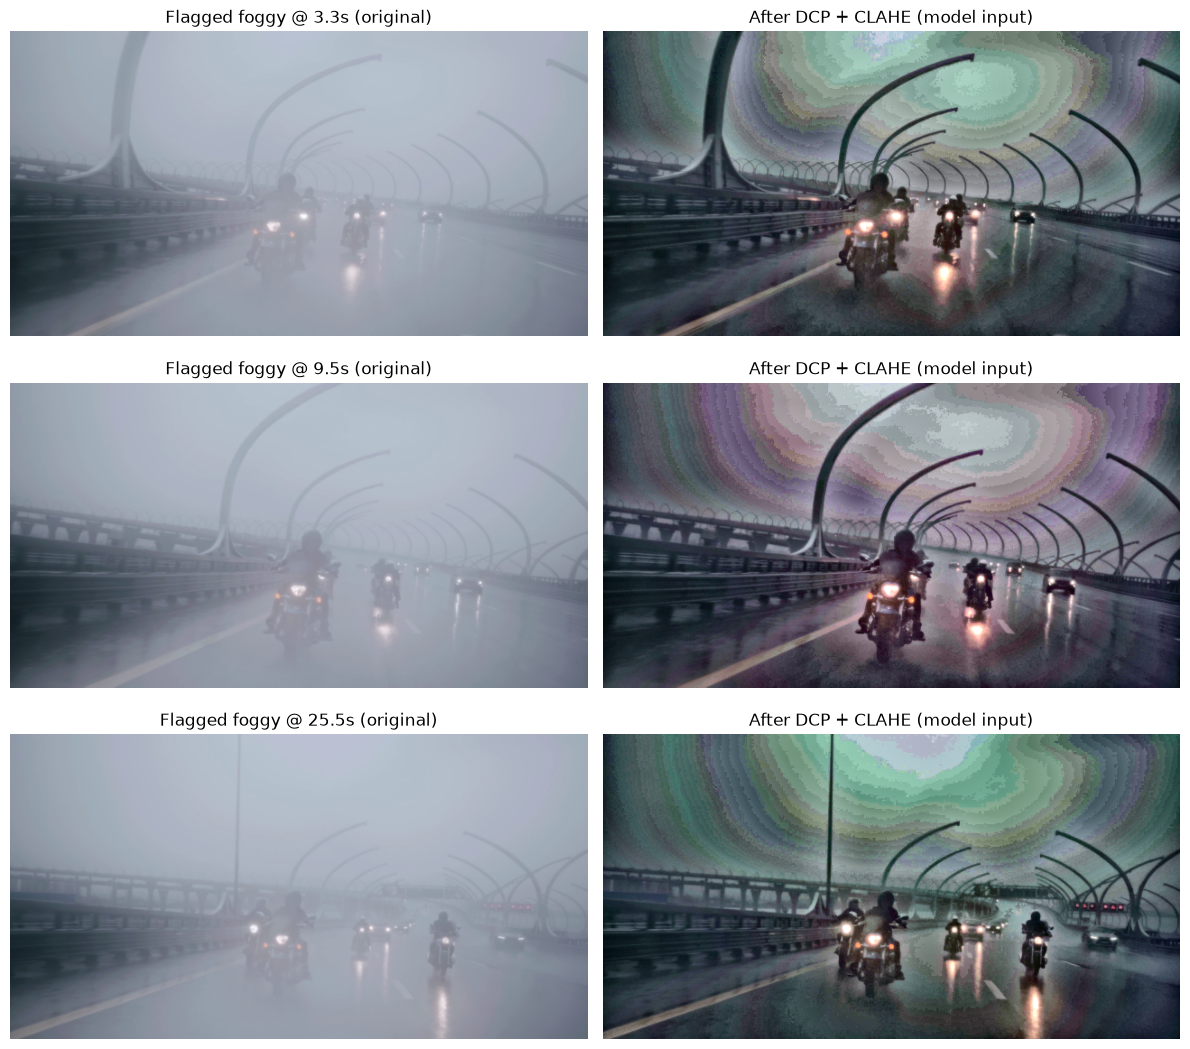

In [224]:
import random
import matplotlib.pyplot as plt

N_EXAMPLES = 3

cap = cv2.VideoCapture(str(input_path))
vid_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
interval = 1 if not CONFIG["TARGET_FPS"] else max(int(round(vid_fps / CONFIG["TARGET_FPS"])), 1)

examples = []   # reservoir sample of (timestamp_sec, small_frame)
sampled = foggy_seen = 0
idx = 0

while cap.grab():                       # grab() skips the costly decode for frames we don't sample
    if idx % interval == 0:
        ok, frame = cap.retrieve()
        if not ok:
            break
        _, small, _, _ = resize_for_model(frame)
        sampled += 1
        if classify_frame(small) == "fog":
            foggy_seen += 1
            if len(examples) < N_EXAMPLES:
                examples.append((idx / vid_fps, small))
            else:
                j = random.randint(0, foggy_seen - 1)   # keeps every foggy frame equally likely
                if j < N_EXAMPLES:
                    examples[j] = (idx / vid_fps, small)
    idx += 1
cap.release()

print(f"{foggy_seen} of {sampled} sampled frames flagged foggy")

if not examples:
    print("No foggy frames found in this video.")
else:
    examples.sort(key=lambda e: e[0])
    fig, axes = plt.subplots(len(examples), 2, figsize=(12, 3.6 * len(examples)), squeeze=False)
    for row, (ts, small) in zip(axes, examples):
        processed = enhance_exposure(dehaze(small))
        row[0].imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB))
        row[0].set_title(f"Flagged foggy @ {ts:.1f}s (original)")
        row[1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
        row[1].set_title("After DCP + CLAHE (model input)")
        for ax in row:
            ax.axis("off")
    plt.tight_layout()
    plt.show()